# IMT 3860 - Introducción a Data Science

# Taller 1: Estadística Descriptiva e Inferencia Estadística.

#### <u> Fecha de entrega Parte 4: Lunes 28 de abril 2025, 23:59.<u>


## 1. Introducción.

En Data Science, recolectamos y evaluamos datos para obtener conclusiones, aplicando para ello diversas técnicas de analisis. Algunas de estas conclusiones o descubrimientos se pueden describirse fácilmente usando tablas y gráficos, lo que conocemos como **estadística descriptiva**. En muchos otros casos, necesitamos explorar una cantidad o variable *no observada* a partir de los datos disponibles, y estimar ciertos parámetros de una población a partir de una muestra representativa. En este caso, recurrimos a la **inferencia estadística**.



El proceso de inferencia estadística concierne al desarrollo de procesos, métodos y teoremas que nos permiten extraer significado e información de data generada por procesos estocásticos (aleatorios).



Tenemos una muestra de una población, y podemos calcular estadísticas descriptivas para ellas, pero ¿son representativas de la población completa? Sabemos que no podemos predecir valores absolutos para otras muestras o mediciones, pero podemos hablar en el lenguaje de probabilidades.

    
    
El objetivo de la inferencia estadística, es obtener conclusiones probabilísticas sobre los resultados que esperamos si volvemos  tomar los mismos datos.





## 2. Caso de Estudio: Análisis de Votaciones Presidenciales en EEUU 2020.


### 2.1 Descripción del Dataset.

Los datos para este problema correspoden a los resultados de las elecciones presidenciales 2020 de EEUU -Biden (demócrata) vs. Trump (republicano)-, a nivel de condados. Además, se incluyen algunas variables sociodemográficos y resultados de elecciones anteriores.

Estos datos pueden ser visualizados en el siguiente mapa de USA Today:

https://www.usatoday.com/in-depth/graphics/2020/11/10/election-maps-2020-america-county-results-more-voters/6226197002/


### 2.2 Objetivo.

Analizar el comportamiento de distintos estados y condados en las elecciones presidenciales estadounidenses 2020. Por ejemplo, algunas preguntas que podríamos responder a partir de los datos son:

- ¿Cómo se distribuyen los condados donde ganó la opción demócrata (Biden) o republicana (Trump)?
- ¿En qué se parecen/diferencian?
- ¿Hay correlaciones entre el porcentaje de voto demócrata (o republicano) y otras variables políticas o sociodemográficas?
- ¿Es el comportamiento de un condado o estado, predictor de otro?
- ¿Hay similitudes entre los swing states?

## 3. Desarrollo.



In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd

### 3.1 Lectura de Datos.

La librería Pandas contiene métodos de lectura de distintos tipos de datos, entre ellos datos en formato `csv`, mediante la función `read_csv`:

https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html


In [3]:
dat=pd.read_csv('county_election_results.csv')


Esta función almacena los datos en una estructura tipo DataFrame, que podemos explorar usando los métodos y atributos descritos en:

https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html



In [4]:
dat.columns

Index(['Unnamed: 0', 'FIPS', 'eevp', 'electTotal', 'electionDate', 'level',
       'office', 'state', 'winner', 'votes_R_2020', 'votes_D_2020',
       'votes_third_party_2020', 'votes_total_2020', 'export_time',
       'acs_pct_pop_nonwhite', 'acs_pct_management', 'acs_pct_service',
       'pct_pop25+_bachelor_higher', 'median_household_income',
       'per_capita_income', 'category_education', 'category_income',
       'category_nonwhite', 'category_jobs_management',
       'category_jobs_service', 'pew_classification', 'region',
       'category_unemployment', 'date', 'POPESTIMATE2019', 'deaths',
       'deaths_per_thousand', 'deaths_percap_pctile', 'cases',
       'cases_per_thousand', 'cases_percap_pctile', 'case_pct_change',
       'BLS_Area_Code', 'Month', 'Month_Str', 'Labor Force', 'Employment',
       'Unemployment', 'Unemployment Rate', 'county', 'pct_2000_dem',
       'pct_2000_gre', 'pct_2000_rep', 'pct_2004_dem', 'pct_2004_rep',
       'pct_2008_dem', 'pct_2008_rep', 'pct_

In [5]:
dat

,Unnamed: 0,FIPS,eevp,electTotal,electionDate,level,office,state,winner,votes_R_2020,...,votes_2000,votes_2004,votes_2008,votes_2012,votes_2016,category_2016_dem,category_2016_rep,votes_d_2016,votes_r_2016,votes_cast_pct_2016
0,0,1061,100,0,2020-11-03,FIPSCode,presidential,AL,R,10848,...,9559,10520,11657,11320,11758,NaN,top 10% Trump by percent vote,1525,9994,1.065913
1,1,1021,100,0,2020-11-03,FIPSCode,presidential,AL,R,16085,...,15092,16693,17785,17462,18369,NaN,top 10% Trump by percent vote,2911,15081,1.049649
2,2,1049,100,0,2020-11-03,FIPSCode,presidential,AL,R,24767,...,20285,24135,24015,23863,25826,NaN,top 10% Trump by percent vote,3622,21405,1.134438
3,3,1093,100,0,2020-11-03,FIPSCode,presidential,AL,R,12205,...,11756,12875,12355,12105,12984,NaN,top 10% Trump by percent vote,1432,11274,1.061537
4,4,1059,100,0,2020-11-03,FIPSCode,presidential,AL,R,10376,...,11103,12269,11693,10859,12040,NaN,NaN,2197,9466,1.043854
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3107,3107,56041,100,0,2020-11-03,FIPSCode,presidential,WY,R,7496,...,7418,8081,8418,8539,8470,NaN,NaN,1202,6154,1.102479
3108,3108,56003,100,0,2020-11-03,FIPSCode,presidential,WY,R,4806,...,4918,5283,5341,5324,5317,NaN,NaN,604,4067,1.074666
3109,3109,56023,100,0,2020-11-03,FIPSCode,presidential,WY,R,8643,...,6845,7914,8615,8618,8875,NaN,NaN,1105,6779,1.170704
3110,3110,56031,100,0,2020-11-03,FIPSCode,presidential,WY,R,3898,...,4373,4574,4597,4531,4529,NaN,NaN,719,3437,1.082358


### 3.2 Análisis Exploratorio.


Analicemos en primer lugar la distribución de condados donde se impuso Biden. Para ello, creamos una nueva columna con el porcentaje de votos demócratas por condado. 

#### 3.2.1 Análisis Gráfico.

Una primera forma de explorar esta información, es mediante un análisis exploratorio mediante un gráfico.

`Funciones de interés:`

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html




Comentarios sobre las similitudes y diferencias (basado en lo que típicamente se espera y verías en los resultados):

Republicanos (pct_R):

Georgia tiende a tener mayores porcentajes de voto republicano en sus condados que Michigan.

La mediana de porcentaje republicano en Georgia es mayor que en Michigan (más condados superan 50% en Georgia).

La dispersión en Georgia es menor: los condados son más consistentemente republicanos.

Michigan tiene más variabilidad: algunos condados son muy republicanos, pero otros no, mostrando un estado más dividido.


Demócratas (pct_D):

Michigan muestra una mediana de votos demócratas más alta que Georgia.

En Michigan hay más condados con porcentajes altos de votos demócratas (sobre todo en áreas urbanas).

Georgia tiene menos condados muy demócratas, pero tiene algunos (como el área de Atlanta) que concentran votos demócratas altos (eso podría generar algunos "outliers" en el boxplot).


Similitudes:

Ambos estados tienen gran dispersión: no todos los condados votan igual, reflejando divisiones urbano-rural.

Ambos presentan condados que están muy lejos de la mediana (outliers).

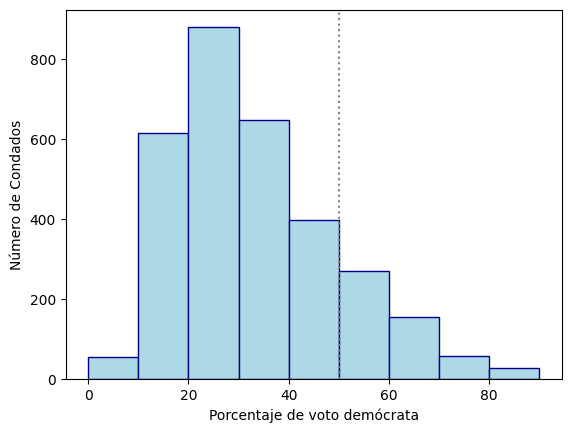

In [6]:
dat['pct_D']=dat['votes_D_2020']/dat['votes_total_2020']*100
#histograma
fig=plt.figure()
ax=fig.add_subplot(111)

bins=np.arange(0,100,10)
n,bins,patches=ax.hist(dat['pct_D'],bins=bins,histtype='bar',ec='darkblue',fc='lightblue')
ax.set_xlabel('Porcentaje de voto demócrata')
ax.set_ylabel('Número de Condados')
ax.axvline(x=50,ls=':',color='gray')

De acuerdo al gráfico, la primera conclusión es que más condados de EEUU votaron por Trump que por el actual presidente Biden.¿Cómo se explica entonces la victoria demócrata?

In [7]:
counties_D=dat[dat['pct_D']>=50.0]
counties_R=dat[dat['pct_D']<50.0]
print(len(counties_R),len(counties_D),len(dat))

2599 513 3112


**Binning bias.**

Lo histogramas son informativos y permiten entender las características genelares de nuestros datos, pero la gran desventaja es que los mismos datos pueden interpretarse de distinta forma dependiendo de la elección de bins. La elección del número de bins es arbitraria, lo cual puede generar sesgos (binning bias). Adicionalmente, en un histograma no estamos graficando todos los datos sino que los agrupamos en bins, y por lo tanto, perdemos sus valores. Una regla común es usar un número de bins igual a la raíz cuadrada del número de muestras.

55


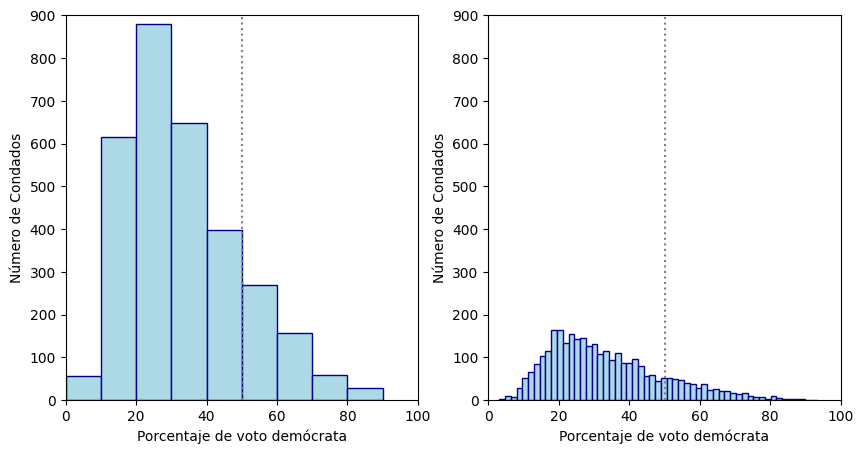

In [8]:
#Notar las diferencias de binning
fig=plt.figure(figsize=(10,5))
ax1=fig.add_subplot(121)
ax2=fig.add_subplot(122)

bins=np.arange(0,100,10)
nbins=int(np.sqrt(len(dat)))
print(nbins)
_=ax1.hist(dat['pct_D'],bins=bins,histtype='bar',ec='darkblue',fc='lightblue')
_=ax2.hist(dat['pct_D'],bins=nbins,histtype='bar',ec='darkblue',fc='lightblue')

for ax in [ax1,ax2]:
    ax.set_xlabel('Porcentaje de voto demócrata')
    ax.set_ylabel('Número de Condados')
    ax.axvline(x=50,ls=':',color='gray')
    ax.set_ylim(0,900)
    ax.set_xlim(0,100)


Para evitar sesgos de bias y pérdidas de información al agrupar los datos, una buena alternativa de exploración gráfica es la **función de distribución acumulada empírica (FDAe)**, donde:
- `Eje x:`la cantidad medida
- `Eje y:` fracción de datos que tienen un valor menor al correspondiente valor `x`.

Para construirla, ordenamos los datos `x`, y construimos un vector `y` de la siguiente forma:

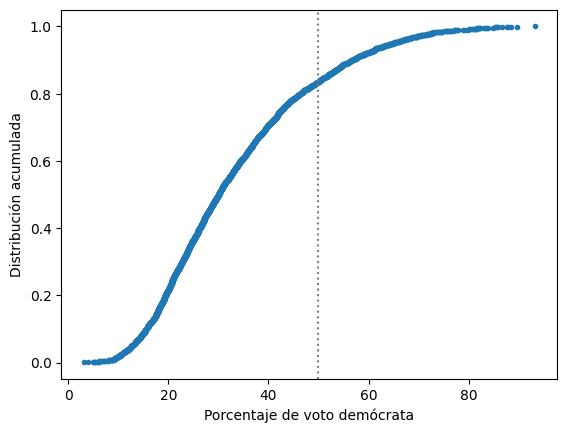

In [9]:
n=len(dat)
x=np.sort(dat['pct_D'])
y=np.arange(1,len(x)+1)/len(x)

plt.plot(x,y,marker='.',ls='none')
plt.xlabel('Porcentaje de voto demócrata')
plt.ylabel('Distribución acumulada')
plt.axvline(x=50,ls=':',color='gray')

Podemos decir por ejemplo, que aproximadamente el 80% de los condados fue ganado por el candidato republicano, ya que tienen un porcentaje de voto demócrata menor al 50%.

La FDAe también es útil para comparar distribuciones. Por ejemplo, podemos comparar las distribuciones en los estados que definieron la elección del 2020: Arizona, Pensylvannia, Michigan, Georgia y Wisconsin.

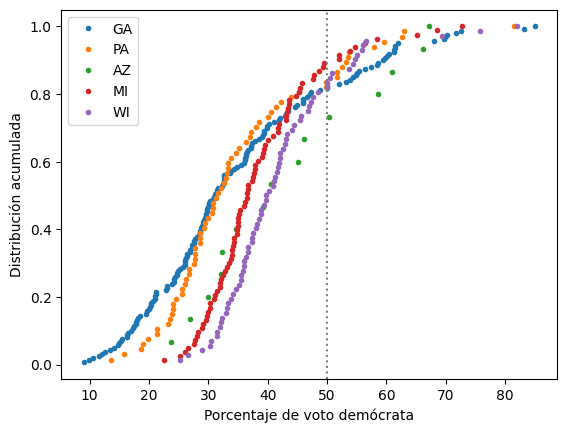

In [10]:
def fdae(data):
    n=len(data)
    x=np.sort(data)
    y=np.arange(1,len(x)+1)/len(x)
    return(x,y)

swing=['GA','PA','AZ','MI','WI',]

for state in swing:
    dats=dat[dat['state']==state]
    x,y=fdae(dats['pct_D'])
    plt.plot(x,y,marker='.',ls='none',label=state)
    plt.legend()
plt.xlabel('Porcentaje de voto demócrata')
plt.ylabel('Distribución acumulada')
plt.axvline(x=50,ls=':',color='gray')

¿Qué estados tienen mayores y menores fracciones de condados ganados por Biden?

#### 3.2.2 Estadísticas de Resumen.

Los histogramas y FDAe entregan un resumen efectivo de los datos, pero puede ser de utilidad resumirlos aún más en algunas estadísticas numéricas, como por ejemplo: 

- **Media** (`np.mean()`): es la suma de todos los valores de los datos, dividida por el número de datos.
 
$$\mu=\frac{1}{n} \sum_{i=1}^n x_i $$

- **Mediana** (`np.median()`): es el valor medio de un conjunto de datos. Es inmune a valores extremos o outliers. Para calcularla, se ordenan los datos y se elige el valor que queda en la mitad. 

 
- **Percentiles** (`np.percentile()`): el percentil $p$, corresponde al valor que es mayor al $p\%$ de los datos.


- **Varianza** (`np.var()`): promedio de la distancia cuadrática de los datos a la media. Es una medida de la dispersión de los datos.

$$\rm{Var}=\frac{1}{n} \sum_{i=1}^n (x_i-\bar{x})^2$$

- **Desviación estándar** (`np.std()`): es la raíz cuadrada de la varianza. Está en la misma escala de unidades que los datos.

$$\sigma=\sqrt{\frac{1}{n} \sum_{i=1}^n (x_i-\bar{x})^2}$$

- **Covarianza** (`np.cov()`): es una medida de cómo dos cantidades varían juntas.
Es la media del producto entre las diferencias de los valores respecto a la media.

$$\rm{Cov} (x,y)=\frac{1}{n} \sum_{i=1}^n (x_i-\bar{x})(y_i-\bar{y})$$

- **Coeficiente de correlación de Pearson** (`np.corrcoef`): para tener una medida más general y aplicable de la correlación entre dos variables, necesitamos que sea adimensional. Por lo tanto dividimos la covarianza por las desviaciones estándar de $x$ e $y$. Esto define el coeficiente de correlación de Pearson ($\rho$).

$$\rho=\frac{\rm{Cov} (x,y)}{\sigma_x \sigma_y}$$


In [11]:
dat.columns

Index(['Unnamed: 0', 'FIPS', 'eevp', 'electTotal', 'electionDate', 'level',
       'office', 'state', 'winner', 'votes_R_2020', 'votes_D_2020',
       'votes_third_party_2020', 'votes_total_2020', 'export_time',
       'acs_pct_pop_nonwhite', 'acs_pct_management', 'acs_pct_service',
       'pct_pop25+_bachelor_higher', 'median_household_income',
       'per_capita_income', 'category_education', 'category_income',
       'category_nonwhite', 'category_jobs_management',
       'category_jobs_service', 'pew_classification', 'region',
       'category_unemployment', 'date', 'POPESTIMATE2019', 'deaths',
       'deaths_per_thousand', 'deaths_percap_pctile', 'cases',
       'cases_per_thousand', 'cases_percap_pctile', 'case_pct_change',
       'BLS_Area_Code', 'Month', 'Month_Str', 'Labor Force', 'Employment',
       'Unemployment', 'Unemployment Rate', 'county', 'pct_2000_dem',
       'pct_2000_gre', 'pct_2000_rep', 'pct_2004_dem', 'pct_2004_rep',
       'pct_2008_dem', 'pct_2008_rep', 'pct_

Covarianza: 1529.2228630936759
Pearson: 0.7003677095910197


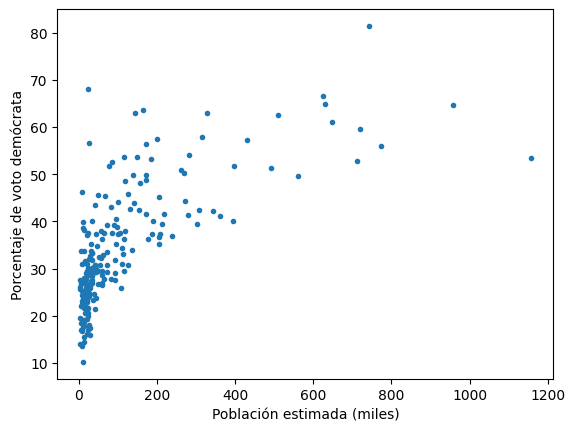

In [12]:
#Análisis de covarianza: % votos demócratas y cantidad total de votantes en swing states
swing=['PA','OH','FL']

dat_swing=dat[dat['state'].isin(swing)]

x=dat_swing['votes_total_2020']/1000
y=dat_swing['pct_D']

cov=np.cov(x,y)
print('Covarianza:',cov[0,1])

pearson=np.corrcoef(x,y)
print('Pearson:',pearson[0,1])

#scatter plot:
_=plt.plot(x,y,'.')
_=plt.xlabel('Población estimada (miles)')
_=plt.ylabel('Porcentaje de voto demócrata')

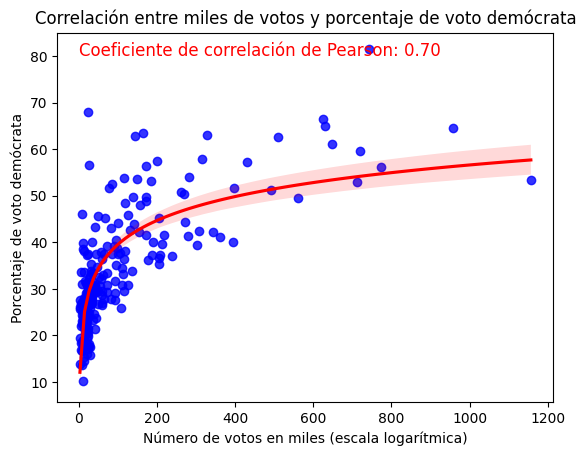

In [13]:
import seaborn as sns

swing=['PA','OH','FL']
dat_swing=dat[dat['state'].isin(swing)]

x=dat_swing['votes_total_2020']/1000
y=dat_swing['pct_D']

cov=np.cov(x,y)
pearson=np.corrcoef(x,y)

sns.regplot(x=x, y=y, logx=True, scatter_kws={"color": "blue"}, line_kws={"color": "red"})
plt.xlabel('Número de votos en miles (escala logarítmica)')
plt.ylabel('Porcentaje de voto demócrata')
plt.title('Correlación entre miles de votos y porcentaje de voto demócrata')
plt.text(1, 80, f'Coeficiente de correlación de Pearson: {pearson[0,1]:.2f}', fontsize=12, color='red')
plt.show()

La función `ns.regplot()` de la biblioteca Seaborn se utiliza para crear un gráfico de dispersión con una línea de regresión. El parámetro `logx=True` se utiliza para indicar que el eje x debe tener una escala logarítmica. La función `plt.text()` se utiliza para añadir el coeficiente de correlación de Pearson como un texto en el gráfico.

### 3.3 Estimación de Parámetros.

Supongamos un caso muy simple en que podemos modelar la relación entre dos variables mediante una regresión lineal de la forma:

$$ y=ax+b $$

donde $a$ y $b$ son parámetros a estimar.

Por ejemplo, podemos modelar la relación entre el porcentaje de voto demócrata, y la cantidad total de votos por condado

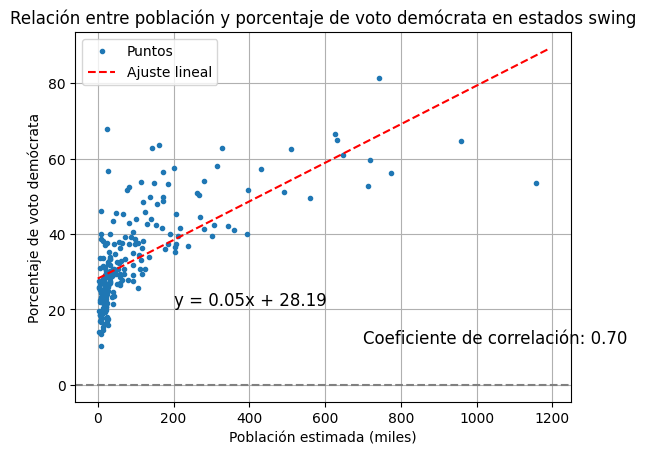

In [14]:
# Ajuste lineal y gráfico de dispersión
a, b = np.polyfit(x, y, 1)
xf = np.arange(0, 1200, 10)
yf = a * xf + b
plt.plot(x, y, '.', label='Puntos')
plt.plot(xf, yf, '--', color='red', label='Ajuste lineal')

# Título, leyenda y etiquetas de los ejes
plt.title('Relación entre población y porcentaje de voto demócrata en estados swing')
plt.xlabel('Población estimada (miles)')
plt.ylabel('Porcentaje de voto demócrata')
plt.legend()

# Coeficiente de correlación
pearson = np.corrcoef(x, y)[0, 1]
plt.text(700, 10, f'Coeficiente de correlación: {pearson:.2f}', fontsize=12, ha='left', va='bottom')
plt.axhline(y=0, color='gray', linestyle='--')

# Ecuación de la recta
plt.text(200, 20, f'y = {a:.2f}x + {b:.2f}', fontsize=12, ha='left', va='bottom')

# Cuadrícula de fondo
plt.grid(True)

# Mostrar el gráfico
plt.show()


### 3.4 Boostrapping.
 
Veamos primero cómo generar remuestreos y réplicas de bootstrapping usando `numpy.random`. Para ello, consideremos los datos de fracción de voto demócrata para todos los condados de EEUU, y su distribución acumulada.

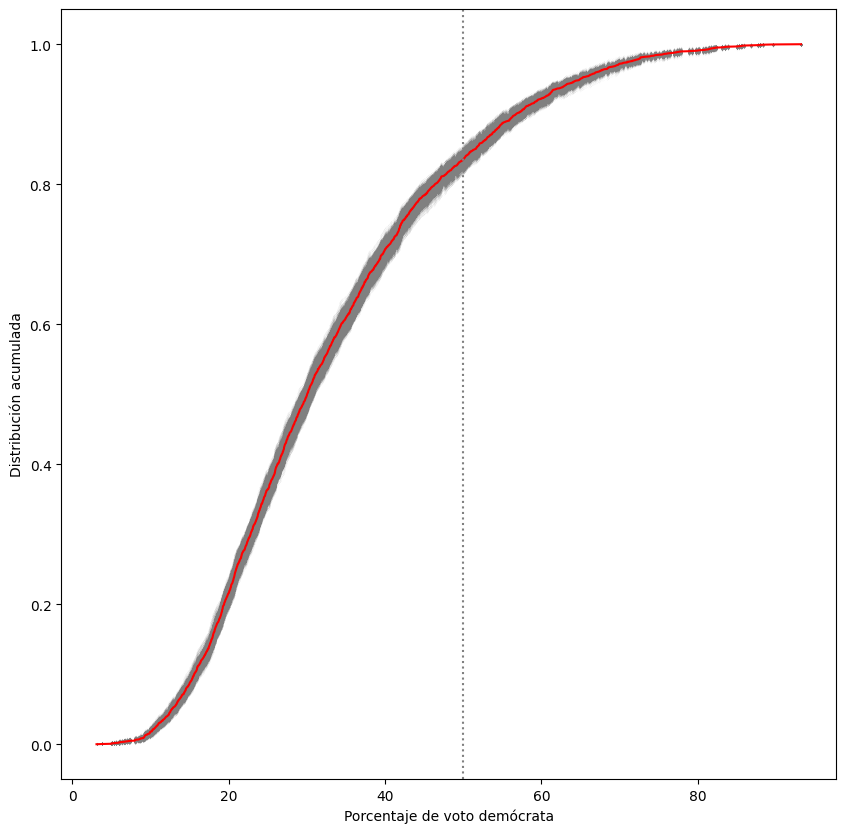

In [15]:
def fdae(data):
    n=len(data)
    x=np.sort(data)
    y=np.arange(1,len(x)+1)/len(x)
    return(x,y)

nsamples=1000
xb=dat['pct_D']
plt.figure(figsize=(10,10))

for ns in range(nsamples):
    bs_sample=np.random.choice(xb,size=len(xb))
    x, y = fdae(bs_sample)
    _ = plt.plot(x, y, marker='.', markersize=0.2,linestyle='none',color='gray', alpha=0.1)
    

x, y = fdae(xb)
_ = plt.plot(x, y, '-', color='red')
 
    
plt.xlabel('Porcentaje de voto demócrata')
plt.ylabel('Distribución acumulada')
plt.axvline(x=50,ls=':',color='gray')


### Bootstrap no paramétrico.

Suponga ahora que por alguna inesperada razón el candidato perdedor logra anular al elección, y ésta tiene que repetirse (bajo las mismas condiciones iniciales). ¿Qué podemos decir del resultado esperado para esta nueva "medición"?

0.1648457583547558
IC (95%): [0.15167095 0.17802057]


(0.0, 110.0)

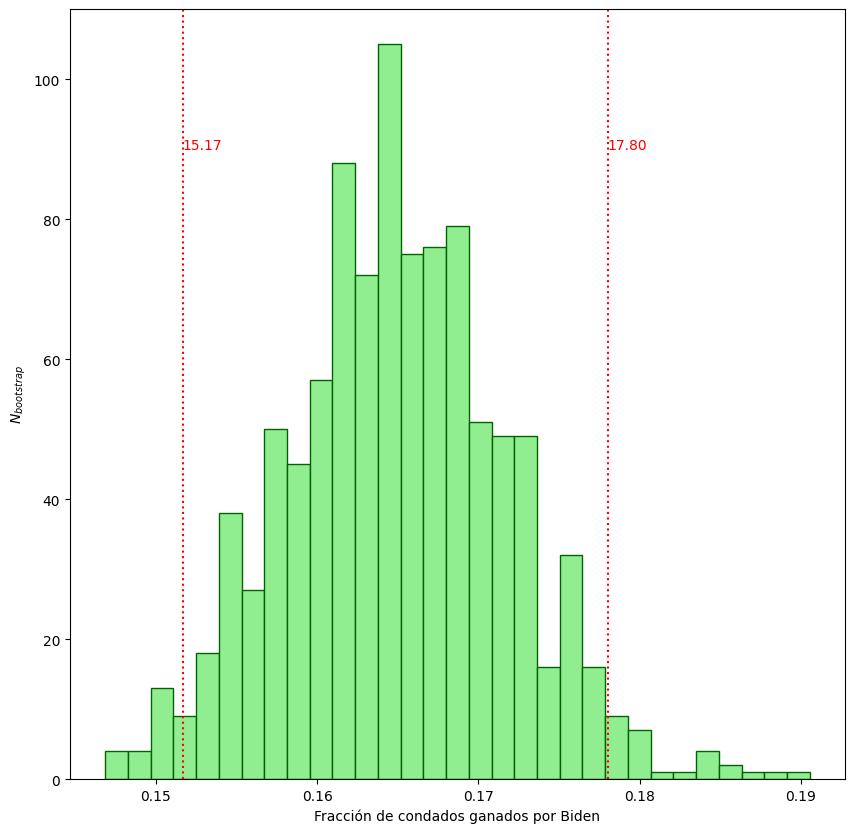

In [16]:
#qué fracción de los condados serían ganados por demócratas si repetimos la elección bajo las mismas condiciones?

nsamples=1000
xb=dat['pct_D']

#estadistica promedio para los datos
counties_D=xb[xb>=50.0]
frac_D=len(counties_D)/len(dat)
print(frac_D)
plt.figure(figsize=(10,10))

frac_D_b=np.empty(nsamples)
for ns in range(nsamples):
    bs_sample=np.random.choice(xb,size=len(xb))
    counties_D_b=bs_sample[bs_sample>=50.0]
    frac_D_b[ns]=len(counties_D_b)/len(bs_sample)


_ = plt.hist(frac_D_b,bins=int(np.sqrt(nsamples)),ec='darkgreen',fc='lightgreen')
 
    
IC=np.percentile(frac_D_b, [2.5, 97.5])
                 
print('IC (95%):',IC)     

plt.xlabel('Fracción de condados ganados por Biden')
plt.ylabel(r'$N_{bootstrap}$')
#plt.axvline(x=frac_D,ls='--',color='k')
plt.axvline(x=IC[0],ls=':',color='r')
plt.axvline(x=IC[1],ls=':',color='r')
plt.text(IC[0],90,'%.2f'%(IC[0]*100),color='r',fontsize=10)
plt.text(IC[1],90,'%.2f'%(IC[1]*100),color='r',fontsize=10)

#plt.fill_betweenx([0,110],0.14,IC[0],alpha=0.2,color='r')
#plt.fill_betweenx([0,110],IC[1],0.2,alpha=0.2,color='r')
plt.ylim(0,110)


A partir de los resultados de la votación del 3/11/2020, podemos *inferir* que si la elección se repitiera (en las mismas condiciones), Biden ganaría entre un 15.1% y 17.7% de los condados, con 95% de confiabilidad.


### 3.5 Boostrapping de a Pares e Intervalos de Confiabilidad.

¿Qué pasaría si repetimos la elección, bajo las mismas condiciones? ¿Cómo cambiarían los parámetros de la función lineal estimada en el punto 3.3 (% de voto demócrata vs. total de votos en FL, OH y PA)? 

Usando bootstrapping, podemos obtener intervalos de confiabilidad para $a, b$: generamos colecciones de pares de datos, y obtenemos la distribución de los parámetros obtenidos.

a: IC (95%): [0.0406562  0.06558387]
b: IC (95%): [26.5566068  29.61193905]


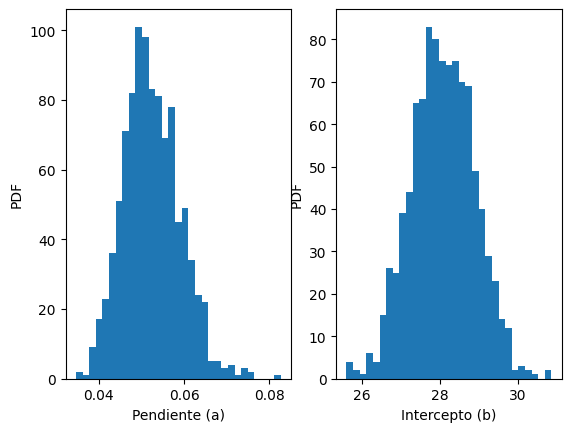

In [17]:
x=dat_swing['votes_total_2020']/1000
y=dat_swing['pct_D']
x=x.to_numpy()
y=y.to_numpy()
#Indices
inds=np.arange(len(x))

#numero de muestras
size=1000 

# Initializar replicas: bs_slope_reps, bs_intercept_reps
bs_slope_reps = np.empty(size)
bs_intercept_reps = np.empty(size)

# Generar replicates
for i in range(size):
    bs_inds = np.random.choice(inds, size=len(inds))
    bs_x, bs_y = x[bs_inds], y[bs_inds]
    bs_slope_reps[i], bs_intercept_reps[i] = np.polyfit(bs_x, bs_y, 1)

print('a: IC (95%):',np.percentile(bs_slope_reps, [2.5, 97.5]))     
print('b: IC (95%):',np.percentile(bs_intercept_reps, [2.5, 97.5]))     
  
# Plot the histogram

f, (ax1, ax2) = plt.subplots(1, 2)

nbins=int(np.sqrt(size))
ax1.hist(bs_slope_reps, bins=nbins)
ax1.set_xlabel('Pendiente (a)')
ax1.set_ylabel('PDF')

ax2.hist(bs_intercept_reps, bins=nbins)
ax2.set_xlabel('Intercepto (b)')
ax2.set_ylabel('PDF')

plt.show()


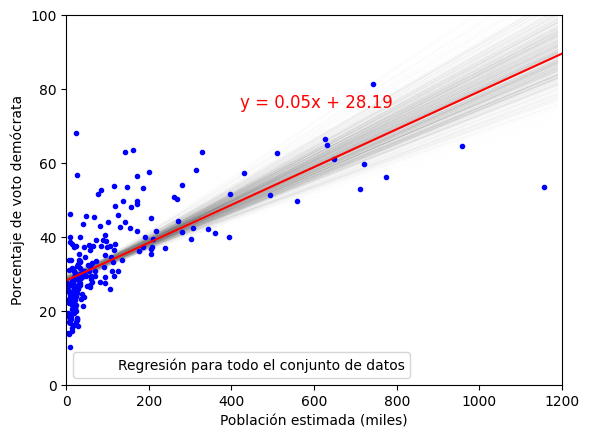

In [18]:
# Dibujar líneas de regresión con diferentes valores de pendiente e intersección
xf = np.arange(0, 1200, 10)
for a, b in zip(bs_slope_reps, bs_intercept_reps):
    plt.plot(xf, a * xf + b, lw=0.1, alpha=0.1, color='gray')

# Dibujar puntos originales
plt.plot(x, y, '.', color='blue')

# Calcular y dibujar la línea de regresión para todo el conjunto de datos
p = np.polyfit(x, y, 1)
xf = np.linspace(0, 1200, 100)
yf = np.polyval(p, xf)
plt.plot(xf, yf, '-', color='red')

# Ajustar los ejes y agregar etiquetas
plt.ylim(0, 100)
plt.xlim(0, 1200)
plt.xlabel('Población estimada (miles)')
plt.ylabel('Porcentaje de voto demócrata')

# Agregar leyenda
plt.legend(['Regresión para todo el conjunto de datos'])

# Imprimir los coeficientes de la recta de regresión para todo el conjunto de datos
eq_text = 'y = {:.2f}x + {:.2f}'.format(p[0], p[1])
plt.text(420, 75, eq_text, fontsize=12, color='red')

plt.show()


### 3.6 Testeo de Hipótesis.

En el análisis anterior asumimos un modelo lineal para la generación de datos, y estimamos los parámetros del modelo junto con sus intervalos de confiabilidad. Pero, ¿cómo evaluamos si el modelo es una descripción razonable de los datos?

Por ejemplo, supongamos la siguiente hipótesis: **dos estados vecinos como Michigan y Wisconsin, tienen la misma distribución de probabilidad de votos a nivel de condado.**
 
Esta es nuestra **hipótesis nula**, y contamos con datos para testearla (validar si es verdadera). En concreto, necesitamos evaluar qué tan razonables son los datos observados, asumiendo que la hipótesis es verdadera.

Podemos comenzar por comparar la distribución acumulada y estadísticas de resumen para cada estado.

MI, media:38.78, mediana:36.57, std:9.62, len:83
WI, media:42.03, mediana:39.97, std:10.31, len:72
Diferencia en media: 3.26
Diferencia en madiana: 3.40
Diferencia en desviación estándar: 0.69


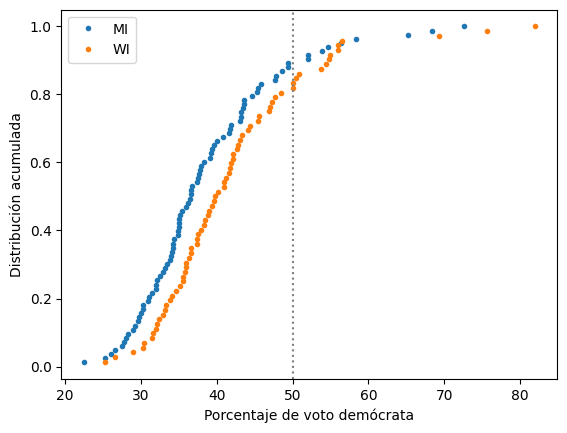

In [19]:
def fdae(data):
    n=len(data)
    x=np.sort(data)
    y=np.arange(1,len(x)+1)/len(x)
    return(x,y)

test=['MI','WI']

for state in test:
    dats=dat[dat['state']==state]
    x,y=fdae(dats['pct_D'])
    plt.plot(x,y,marker='.',ls='none',label=state)
    plt.legend()
    
    print('%s, media:%.2f, mediana:%.2f, std:%.2f, len:%.d'%(state,dats['pct_D'].mean(),dats['pct_D'].median(),dats['pct_D'].std(),len(dats['pct_D'])))
    
mi_dats = dat[dat['state'] == 'MI']
wi_dats = dat[dat['state'] == 'WI']

diff_mean = mi_dats['pct_D'].mean() - wi_dats['pct_D'].mean()
diff_median = mi_dats['pct_D'].median() - wi_dats['pct_D'].median()
diff_std = mi_dats['pct_D'].std() - wi_dats['pct_D'].std()

print('Diferencia en media: %.2f' % abs(diff_mean))
print('Diferencia en madiana: %.2f' % abs(diff_median))
print('Diferencia en desviación estándar: %.2f' % abs(diff_std))

plt.xlabel('Porcentaje de voto demócrata')
plt.ylabel('Distribución acumulada')
plt.axvline(x=50,ls=':',color='gray')



¿Es suficiente este análisis para llegar a una conclusión?

Para testear la hipótesis podemos simular cómo serían los datos observados si las tendencias de voto en ambos estados estuvieran idénticamente distribuidas.

Para ello, reordenamos los datos de manera que los datos de MI y WI sean indistinguibles entre sí. Es decir, como si provinieran de una única población donde el estado no importa. Esto se denomina `permutaciones`, y está implementado en la siguiente función:

https://numpy.org/doc/stable/reference/random/generated/numpy.random.permutation.html

Luego, etiquetamos los primeros datos como 'MI', y los siguientes como 'WI', y calculamos su distribución.

83 72


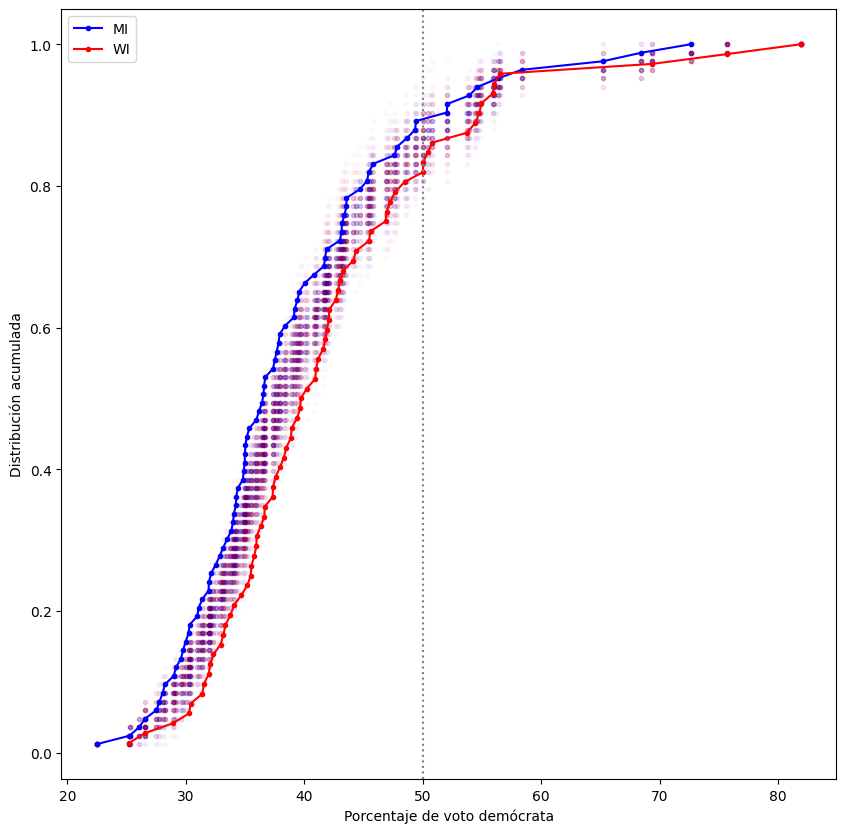

In [20]:
"""Generar una permutacion de dos datasets"""
def permutation_sample(data1, data2):

    #datos concatenados
    data = np.concatenate((data1, data2))

    # permutacion
    permuted_data = np.random.permutation(data)

    #muestras permutadas
    perm_sample_1 = permuted_data[:len(data1)]
    perm_sample_2 = permuted_data[len(data2):]

    return perm_sample_1, perm_sample_2


#datos por estado
pct_D_MI=dat[dat['state']=='MI']['pct_D']
pct_D_WI=dat[dat['state']=='WI']['pct_D']
print(len(pct_D_MI),len(pct_D_WI))
#generamos n permutaciones
nperm=100
plt.figure(figsize=(10,10))
for n in range(nperm):
    perm1,perm2=permutation_sample(pct_D_MI,pct_D_WI)
    x,y=fdae(perm1)
    plt.plot(x,y,marker='.',ls='none',color='blue',alpha=0.02)
    
    x,y=fdae(perm2)
    plt.plot(x,y,marker='.',ls='none',color='red',alpha=0.02)

#graficamos las distribuciones originales de cada estado
x,y=fdae(pct_D_MI)
plt.plot(x,y,marker='.',ls='-',label='MI',color='blue')

x,y=fdae(pct_D_WI)
plt.plot(x,y,marker='.',ls='-',label='WI',color='red')
plt.legend()

plt.xlabel('Porcentaje de voto demócrata')
plt.ylabel('Distribución acumulada')
plt.axvline(x=50,ls=':',color='gray')



Ahora que sabemos cómo simular la hipótesis nula usando permutaciones, podemos testearla. Ello implica evaluar si los datos observados son consistentes asumiendo que la hipótesis es verdadera. ¿Cómo hacemos esto cuantitativamente?

Para evaluar la hipótesis, necesitamos una **estadística de prueba**. Es decir, una cantidad que podemos calcular a partir de las observaciones, y de los datos simulados bajo la hipótesis nula. Esta estadística tiene que ser pertinente a la hipótesis que estamos testeando.

En este caso, la hipotésis nula es: 
> $H_0$: los dos estados (WI y MI) tienen la misma distribución de voto demócrata. 

Es decir, su media debería ser idéntica, o *la diferencia entre sus medias* debería ser 0. Por lo tanto, elegimos como estadística de prueba esta diferencia.

Luego, para evaluar si la estadística de prueba (en este caso, la diferencia entre medias) observada es consistente con la hipótesis nula, analizamos la distribución de réplicas y calculamos el **valor-p**.

> El valor p se define como la probabilidad de que un valor estadístico calculado sea posible dada una hipótesis nula cierta. En términos simples, el valor p ayuda a diferenciar resultados que son producto del azar del muestreo, de resultados que son estadísticamente significativos.

Si el valor p cumple con la condición de ser menor que un nivel de significancia impuesto arbitrariamente, este se considera como un resultado estadísticamente significativo y, por lo tanto, permite *rechazar la hipótesis nula*. Típicamente, se rechaza la hipótesis nula cuando $p<0.05$.


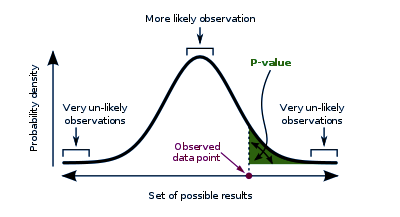



Diferencia promedio observada:3.26
valor-p = 0.0293


Text(0, 0.5, 'N')

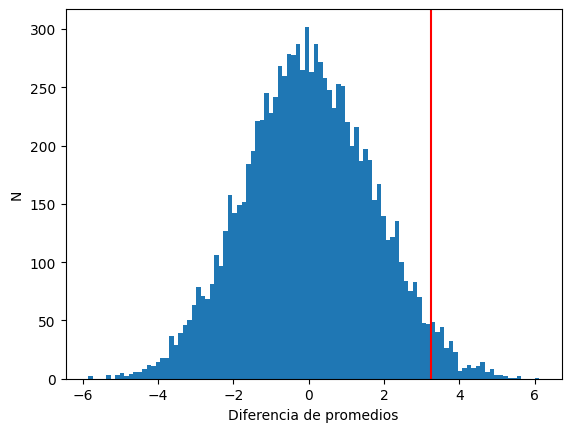

In [21]:
"""Generate multiples replicas de la diferencia media para las permutaciones."""
def perm_reps(data_1, data_2, size=1):

    # Initializar arreglo dereplicas
    perm_replicates = np.empty(size)

    for i in range(size):
        # Generar permutacion
        perm_sample_1, perm_sample_2 = permutation_sample(data_1, data_2)

        # Compute the test statistic
        perm_replicates[i] = perm_sample_1.mean()-perm_sample_2.mean()

    return perm_replicates

#observaciones (MI-WI)
obs_diff=pct_D_WI.mean()-pct_D_MI.mean()

print(r'Diferencia promedio observada:%.2f'%obs_diff)

#permutaciones
nperm=10000
perm_replicates =perm_reps(pct_D_WI,pct_D_MI, size=nperm)

#valor-p
pval=np.sum(perm_replicates>=obs_diff)/len(perm_replicates)
print('valor-p =', pval)

_=plt.hist(perm_replicates,bins=100)
_=plt.axvline(x=obs_diff,color='r',label='Observed difference')
plt.xlabel('Diferencia de promedios')
plt.ylabel('N')

El valor p obtenido indica que hay sólo un 2.2% de probabilidad de obtener las diferencia media observada (3.26%) bajo la hipótesis nula de que las distribuciones de voto demócrata en MI y WI son equivalentes. Es decir, **se rechaza la hipótesis nula**: MI y WI *no* tienen una diferencia de media significativamente igual a 0, por lo tanto sus distribuciones no son similares.

## 4. Trabajo de grupos de máximo 3 integrantes

**1.** Elijan dos estados de EEUU y compare la distribución de votos republicanos y demócratas a través de estadísticas descriptivas. Elabore también un gráfico de caja, y comente sobre las similitudes y diferencias que puede inferir a partir del análisis exploratorio gráfico y cuantitativo.<br>


**2.** A partir de los datos entregados, estudie la posible correlación entre la fracción de votos republicanos (o demócratas) y alguna otras de las variables incluidas en la base de datos. Puede trabajar con todos los estados, o con alguna selección de ellos. Para este estudio, se requiere:<br>

a) Explorar y proponer una posible correlación o relación analítica entre variables.<br>
b) Plantear una hipótesis que refleje esta correlación.<br>
c) Diseñar y realizar el test de hipótesis.<br>
d) Concluir acerca de la validez y significancia de la correlación identificada.<br>

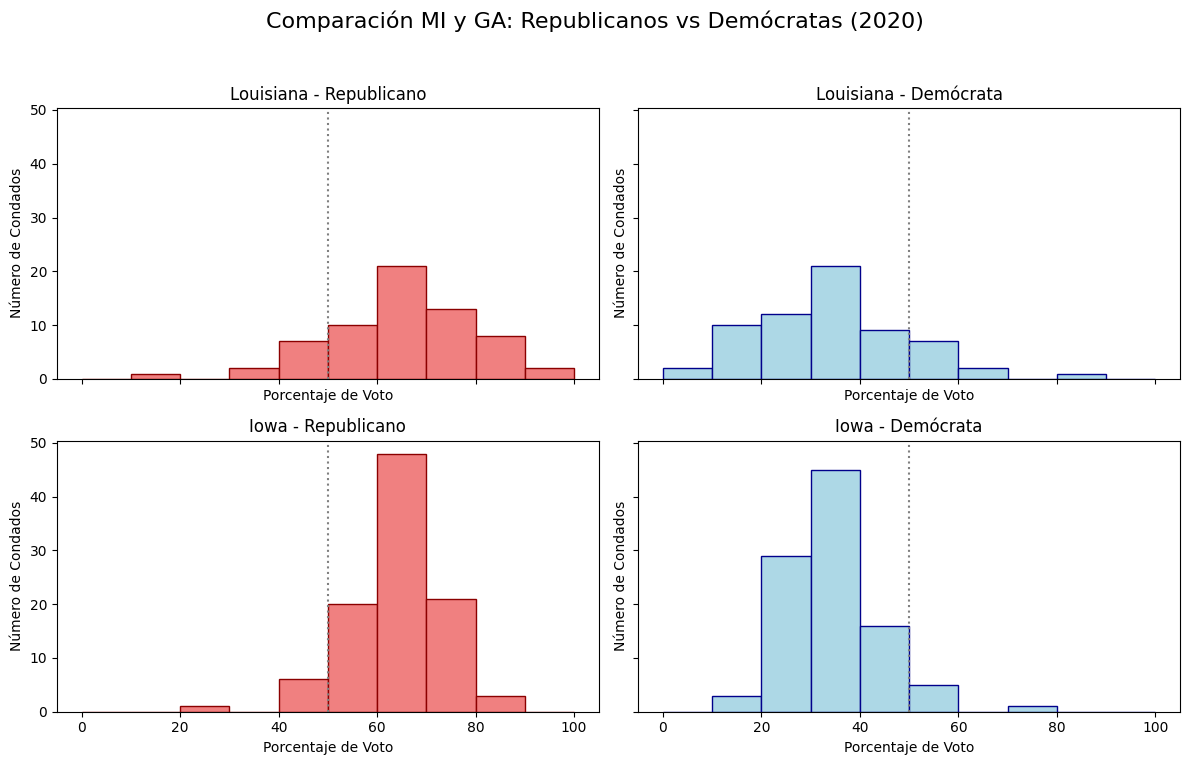

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos
dat=pd.read_csv('county_election_results.csv')

# Calcular porcentajes
dat['pct_R'] = dat['votes_R_2020'] / dat['votes_total_2020'] * 100
dat['pct_D'] = dat['votes_D_2020'] / dat['votes_total_2020'] * 100

# Filtrar Michigan (MI) y Georgia (GA)
dat_LA = dat[dat['state'] == 'LA']
dat_IA = dat[dat['state'] == 'IA']

# Crear figura
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
bins = np.arange(0, 110, 10)

# Histograma LA - Republicano
axs[0,0].hist(dat_LA['pct_R'], bins=bins, color='lightcoral', edgecolor='darkred')
axs[0,0].axvline(x=50, ls=':', color='gray')
axs[0,0].set_title('Louisiana - Republicano')

# Histograma LA - Demócrata
axs[0,1].hist(dat_LA['pct_D'], bins=bins, color='lightblue', edgecolor='darkblue')
axs[0,1].axvline(x=50, ls=':', color='gray')
axs[0,1].set_title('Louisiana - Demócrata')

# Histograma GA - Republicano
axs[1,0].hist(dat_IA['pct_R'], bins=bins, color='lightcoral', edgecolor='darkred')
axs[1,0].axvline(x=50, ls=':', color='gray')
axs[1,0].set_title('Iowa - Republicano')

# Histograma GA - Demócrata
axs[1,1].hist(dat_IA['pct_D'], bins=bins, color='lightblue', edgecolor='darkblue')
axs[1,1].axvline(x=50, ls=':', color='gray')
axs[1,1].set_title('Iowa - Demócrata')

# Ajustes
for ax in axs.flat:
    ax.set(xlabel='Porcentaje de Voto', ylabel='Número de Condados')

fig.suptitle('Comparación MI y GA: Republicanos vs Demócratas (2020)', fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

Media (%)  Mediana (%)  Desviación Estándar (%)  \
Louisiana Demócrata         34.1         33.6                     14.5   
          Republicano       65.0         65.4                     14.5   
Iowa      Demócrata         34.6         32.5                      9.2   
          Republicano       64.1         66.2                      9.4   

                       Mínimo (%)  Máximo (%)  
Louisiana Demócrata           8.1        83.9  
          Republicano        15.1        91.3  
Iowa      Demócrata          15.6        71.0  
          Republicano        27.5        83.4

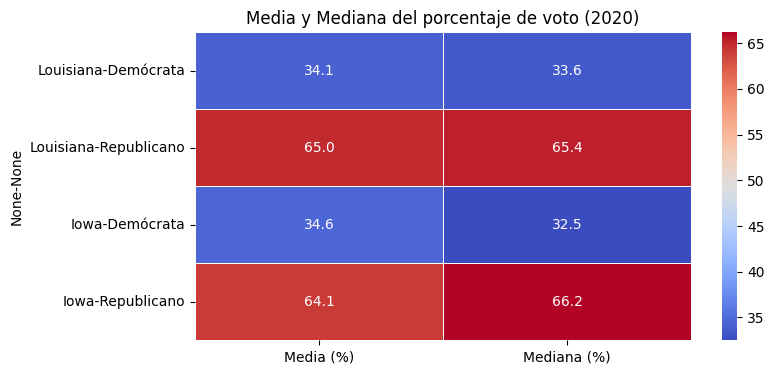

In [23]:

import pandas as pd
import numpy as np

# Cargar el archivo
dat=pd.read_csv('county_election_results.csv')

# Calcular porcentajes
dat['pct_R'] = dat['votes_R_2020'] / dat['votes_total_2020'] * 100
dat['pct_D'] = dat['votes_D_2020'] / dat['votes_total_2020'] * 100

# Filtrar estados
dat_LA = dat[dat['state'] == 'LA']
dat_IA = dat[dat['state'] == 'IA']

# Función para estadística descriptiva
def resumen_estadistico(df, columna):
    return {
        'Media (%)': df[columna].mean(),
        'Mediana (%)': df[columna].median(),
        'Desviación Estándar (%)': df[columna].std(),
        'Mínimo (%)': df[columna].min(),
        'Máximo (%)': df[columna].max()
    }

# Crear DataFrame resumen
resumen = pd.DataFrame({
    ('Louisiana', 'Demócrata'): resumen_estadistico(dat_LA, 'pct_D'),
    ('Louisiana', 'Republicano'): resumen_estadistico(dat_LA, 'pct_R'),
    ('Iowa', 'Demócrata'): resumen_estadistico(dat_IA, 'pct_D'),
    ('Iowa', 'Republicano'): resumen_estadistico(dat_IA, 'pct_R')
}).T

# Mostrar resumen
resumen = resumen.round(1)  # redondear a 1 decimal
display(resumen)

# Opcional: formatear bonito
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8,4))
sns.heatmap(resumen[['Media (%)', 'Mediana (%)']], annot=True, cmap="coolwarm", fmt=".1f", linewidths=.5, ax=ax)
ax.set_title('Media y Mediana del porcentaje de voto (2020)')
plt.show()

Tanto en lowa como en Louisiana predomina el voto republicano.
lowa es menos polarizado: hay menos
condados extremos (ni ultra-demócratas ni ultra-republicanos).
Louisiana muestra mayor variabilidad
en el porcentaje de votos, reflejando una polarización más intensa.
La relación media-medianas muestra ligeras asimetrías, sobre todo en lowa para el voto demócrata (mediana menor que la media).

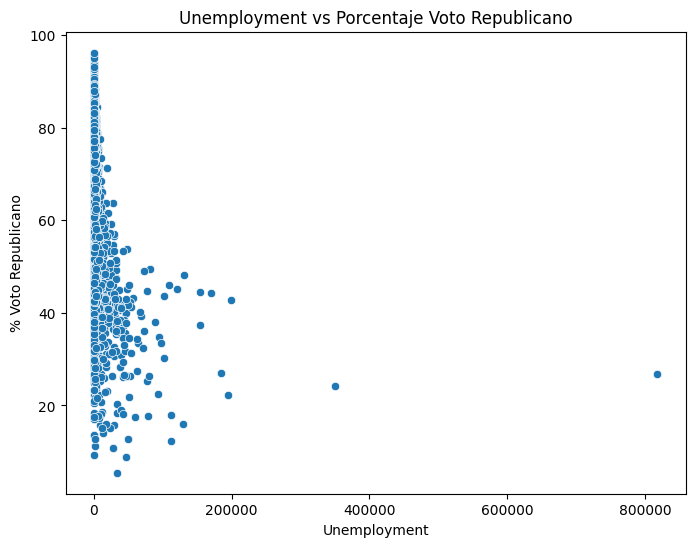

Coeficiente de correlación (r): -0.2953
Valor p (p-value): 1.2043e-63

Conclusión: Se rechaza la hipótesis nula. Existe una correlación significativa.
La relación es negativa: a mayor Unemployment, menor porcentaje de votos republicanos.


In [24]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cargar datos
dat=pd.read_csv('county_election_results.csv')

# Calcular porcentajes
dat['pct_R'] = dat['votes_R_2020'] / dat['votes_total_2020'] * 100
dat['pct_D'] = dat['votes_D_2020'] / dat['votes_total_2020'] * 100


# Si se llama diferente, debes ajustar el nombre aquí:
target_column = 'Unemployment'

# Explorar visualmente
plt.figure(figsize=(8,6))
sns.scatterplot(x=dat[target_column], y=dat['pct_R'])
plt.title('Unemployment vs Porcentaje Voto Republicano')
plt.xlabel('Unemployment')
plt.ylabel('% Voto Republicano')
plt.show()

# Hipótesis
# H0: No hay correlación entre Unemployment e % de voto republicano
# H1: Hay correlación entre Unemployment % de voto republicano

# Prueba de Pearson
corr_r, p_value = stats.pearsonr(dat[target_column], dat['pct_R'])

print(f"Coeficiente de correlación (r): {corr_r:.4f}")
print(f"Valor p (p-value): {p_value:.4e}")

# Conclusión
if p_value < 0.05:
    print("\nConclusión: Se rechaza la hipótesis nula. Existe una correlación significativa.")
    if corr_r < 0:
        print("La relación es negativa: a mayor Unemployment, menor porcentaje de votos republicanos.")
    else:
        print("La relación es positiva: a mayor Unemployment, mayor porcentaje de votos republicanos.")
else:
    print("\nConclusión: No se rechaza la hipótesis nula. No existe correlación significativa.")